## ** Advanced Python Data Exploration & Automated Reporting**



### Business Scenario

This project focuses on developing an automated analytical solution for a multinational retail company to monitor and evaluate **sales, profitability, customer behavior, and operational performance**.

The project applies a complete data analysis workflow, starting from data inspection and cleaning, through exploratory and statistical analysis, and ending with automated reporting and visualization.

### Project Workflow

The analysis will follow these main stages:

1. **Data Import & Inspection**
2. **Data Cleaning & Quality Checks**
3. **Data Transformation & Preprocessing**
4. **Feature Engineering**
5. **Modular Analytical Functions**
6. **Exploratory Data Analysis (EDA)**
7. **Statistical Analysis**
8. **Data Visualization**
9. **KPI Analysis & Automated Reporting**
10. **Exporting Cleaned Data & Visual Reports**
11. **Performance & Memory Optimization**

### Project Objective

The main objective is to build a **reusable, scalable, and automated data analysis workflow** that transforms raw retail data into meaningful business insights and analytical reports.

---

**Tools & Technologies:**
Python • Pandas • NumPy • Matplotlib • Seaborn


In [18]:
#Import LI=ibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [19]:
df = pd.read_excel("/content/Sample - Superstore 2019 (3).xls")

In [20]:
df.shape

(9994, 21)

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

Everything is fine except for the “Postal Code” column in the table—it has some missing values, but only a small percentage.  

In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2019-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2018-04-30 10:03:51.979187712,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2018-05-04 09:03:29.645787392,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observation: Potential outliers may exist in Sales and Profit due to the large gap between the median and maximum values. Negative Profit values also indicate that some transactions resulted in losses and should be investigated further.

In [24]:
#Data cleaning
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [25]:
df = df.dropna(subset=["Postal Code"]).copy()

In [26]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


**Observation:** Only **11 missing values** were found in **Postal Code**. Since they represent a very small portion of the dataset, I decided to remove these rows using `dropna()` rather than imputing the values.


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df["Quantity"].describe()

,Quantity
count,9983.000000
mean,3.788741
std,2.223566
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,14.000000


In [29]:
(df["Quantity"] <= 0).sum()

np.int64(0)

In [30]:
(df["Sales"] < 0).sum()

np.int64(0)

In [31]:
df["Discount"].describe()

,Discount
count,9983.000000
mean,0.156375
std,0.206501
min,0.000000
25%,0.000000
50%,0.200000
75%,0.200000
max,0.800000


In [32]:
(df["Discount"] < 0).sum()
(df["Discount"] > 1).sum()

np.int64(0)

In [33]:
(df["Ship Date"] < df["Order Date"]).sum()

np.int64(0)

In [34]:
df["Ship Mode"].unique()
df["Segment"].unique()
df["Region"].unique()
df["Category"].unique()
df["Sub-Category"].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

**Data is Clean 100%**

Overall Observation: Based on these validation checks, no major data quality issues were detected. The dataset is considered clean for the next stage, while potential outliers will be investigated separately during the analysis.

# Advanced Data Cleaning (Outliers, Inconsistent Formats, Duplicates)

In [35]:
# 1. Duplicate records: explicit removal (defensive, in case any exist)
before_rows = len(df)
df = df.drop_duplicates().copy()
after_rows = len(df)
print(f"Duplicate rows removed: {before_rows - after_rows}")
print(f"Remaining rows: {after_rows}")


Duplicate rows removed: 0
Remaining rows: 9983


In [36]:
# 2. Inconsistent formats: standardize text columns (strip whitespace, consistent casing)
text_cols = df.select_dtypes(include="object").columns.tolist()

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardize known categorical text fields to title case for consistency
for col in ["Ship Mode", "Segment", "Region", "Category", "Sub-Category", "Country/Region"]:
    if col in df.columns:
        df[col] = df[col].str.title()

print("Text columns standardized (whitespace stripped, consistent casing applied).")


Text columns standardized (whitespace stripped, consistent casing applied).


In [37]:
# 3. Outlier detection using the IQR method (Sales & Profit)
def detect_outliers_iqr(series, k=1.5):
    """Returns a boolean mask of outliers in a numeric series using the IQR rule."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound


sales_outliers, sales_low, sales_high = detect_outliers_iqr(df["Sales"])
profit_outliers, profit_low, profit_high = detect_outliers_iqr(df["Profit"])

print(f"Sales outliers: {sales_outliers.sum()} rows (bounds: {sales_low:.2f} to {sales_high:.2f})")
print(f"Profit outliers: {profit_outliers.sum()} rows (bounds: {profit_low:.2f} to {profit_high:.2f})")


df["Is Sales Outlier"] = sales_outliers
df["Is Profit Outlier"] = profit_outliers

print(f"\nTotal rows flagged as an outlier in either Sales or Profit: "
      f"{(df['Is Sales Outlier'] | df['Is Profit Outlier']).sum()}")


Sales outliers: 1162 rows (bounds: -271.66 to 498.84)
Profit outliers: 1877 rows (bounds: -39.66 to 70.70)

Total rows flagged as an outlier in either Sales or Profit: 2116


**Observation:** Duplicates were removed defensively, text fields were standardized to a consistent format (trimmed whitespace, title case), and outliers in Sales and Profit were detected using the IQR method. Rather than deleting these outliers, they are **flagged** in two new columns (`Is Sales Outlier`, `Is Profit Outlier`), since unusually high sales or negative-profit transactions are often genuine business events (bulk orders, heavily discounted loss-making sales) that are important to keep visible for analysis rather than discard.

# Reusable Preprocessing Pipeline

In [38]:
def clean_data(raw_df):
    """Applies the full cleaning routine to a raw dataframe: missing values,
    duplicates, inconsistent text formats, and outlier flagging."""
    data = raw_df.copy()

    # Missing values
    data = data.dropna(subset=["Postal Code"])

    # Duplicates
    data = data.drop_duplicates()

    # Inconsistent formats
    text_cols = data.select_dtypes(include="object").columns.tolist()
    for col in text_cols:
        data[col] = data[col].astype(str).str.strip()
    for col in ["Ship Mode", "Segment", "Region", "Category", "Sub-Category", "Country/Region"]:
        if col in data.columns:
            data[col] = data[col].str.title()

    # Outlier flags
    for col in ["Sales", "Profit"]:
        mask, _, _ = detect_outliers_iqr(data[col])
        data[f"Is {col} Outlier"] = mask

    return data


def engineer_features(data):
    """Adds derived feature columns used throughout the analysis."""
    data = data.copy()
    data["Shipping Duration"] = (data["Ship Date"] - data["Order Date"]).dt.days
    data["Profit Margin"] = (data["Profit"] / data["Sales"]) * 100
    data["Sales Performance Category"] = pd.qcut(
        data["Sales"], q=3, labels=["Low", "Medium", "High"]
    )
    return data


def optimize_dtypes(data):
    """Downcasts numeric columns and converts low-cardinality text columns to category dtype."""
    data = data.copy()
    for col in data.select_dtypes(include=["int64"]).columns:
        data[col] = pd.to_numeric(data[col], downcast="integer")
    for col in data.select_dtypes(include=["float64"]).columns:
        data[col] = pd.to_numeric(data[col], downcast="float")
    for col in ["Ship Mode", "Segment", "Country/Region", "Region", "Category", "Sub-Category"]:
        if col in data.columns:
            data[col] = data[col].astype("category")
    return data


def preprocessing_pipeline(filepath):
    """End-to-end reusable pipeline: load -> clean -> engineer features -> optimize dtypes.
    Running this single function on a fresh Superstore export reproduces the entire
    preprocessing stage of this project."""
    raw = pd.read_excel(filepath)
    cleaned = clean_data(raw)
    featured = engineer_features(cleaned)
    optimized = optimize_dtypes(featured)
    return optimized


# Demonstration: rebuild the dataset from scratch using only the pipeline function
df_pipeline = preprocessing_pipeline("/content/Sample - Superstore 2019 (3).xls")
print("Pipeline output shape:", df_pipeline.shape)
df_pipeline.head()


Pipeline output shape: (9983, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Is Sales Outlier,Is Profit Outlier,Shipping Duration,Profit Margin,Sales Performance Category
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.913601,False,False,3,16.00,High
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.582001,True,True,3,30.00,High
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.871400,False,False,4,47.00,Low
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.031006,True,True,7,-40.00,High
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.516400,False,False,7,11.25,Low


**Observation:** The entire cleaning, feature engineering, and memory-optimization stage of this project can now be reproduced with a single call to `preprocessing_pipeline(filepath)`. This makes the workflow reusable on any future Superstore export (e.g. a new quarter or region) without rewriting any code.

In [39]:
#Indexing & Filtering
east_sales = df.loc[
    df["Region"] == "East"
]

In [40]:
high_sales = df.loc[
    df["Sales"] > df["Sales"].median()
]

In [41]:
q4_orders = df.loc[
    df["Order Date"].dt.quarter == 4
]

Observation: The filtering results allow us to focus on specific business segments, such as East region sales, above-median sales, and Q4 orders, which can help identify differences in sales performance across regions, order values, and time periods.

In [42]:
#Feature Engineering
df["Shipping Duration"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [43]:
df["Profit Margin"] = (
    df["Profit"] / df["Sales"]
) * 100

In [44]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Is Sales Outlier,Is Profit Outlier,Shipping Duration,Profit Margin
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,False,False,3,16.00
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,True,True,3,30.00
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,False,False,4,47.00
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,True,True,7,-40.00
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,False,False,7,11.25


Observation: The new features reveal variation in shipping time and profitability. Negative Profit Margin values indicate loss-making transactions, while some unusually high margins may require further investigation.

In [45]:
# Grouping & Aggregation
monthly_sales = (
    df.groupby(
        df["Order Date"].dt.to_period("M")
    )["Sales"]
    .sum()
    .reset_index()
)

In [46]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

In [47]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

In [48]:
monthly_sales

,Order Date,Sales
0,2016-01,14236.8950
1,2016-02,4519.8920
2,2016-03,55691.0090
3,2016-04,28295.3450
4,2016-05,23648.2870
5,2016-06,34595.1276
6,2016-07,33946.3930
7,2016-08,27909.4685
8,2016-09,81777.3508
9,2016-10,31453.3930


Observation: Monthly sales show noticeable fluctuations throughout the period, with some months achieving significantly higher sales than others. Sales generally tend to increase over the years, with the highest monthly sales recorded in November 2019 (~118.4K), followed by December 2019 (~83.6K) and September 2019 (~87.9K). This suggests possible seasonal patterns and overall sales growth over time.

In [49]:
print("Invalid Quantity:", (df["Quantity"] <= 0).sum())
print("Invalid Sales:", (df["Sales"] <= 0).sum())
print("Invalid Discount:", ((df["Discount"] < 0) | (df["Discount"] > 1)).sum())

Invalid Quantity: 0
Invalid Sales: 0
Invalid Discount: 0


No invalid values were detected in Quantity, Sales, or Discount. All quantities and sales values are positive, and all discount values fall within the valid range of 0–1 (0%–100%). Therefore, no additional corrections are required for these fields.

# ##Exploratory Data Analysis (EDA)

In [50]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9983.0,229.216818,621.909610,0.444,17.2800,54.3840,209.9050,22638.480
Quantity,9983.0,3.788741,2.223566,1.000,2.0000,3.0000,5.0000,14.000
Discount,9983.0,0.156375,0.206501,0.000,0.0000,0.2000,0.2000,0.800
Profit,9983.0,28.463592,234.122107,-6599.978,1.7271,8.6436,29.3152,8399.976


Observation: The descriptive statistics show noticeable variability in Sales and especially Profit, with a large gap between the median and maximum values, suggesting the presence of potential outliers. Profit also contains significant negative values, indicating loss-making transactions. Quantity appears relatively stable, while Discount is mostly concentrated around 0–20%, with a maximum of 80% that may require further investigation.

In [51]:
#Categorical Analysis
categorical_cols = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Ship Mode:
Ship Mode
Standard Class    5958
Second Class      1944
First Class       1538
Same Day           543
Name: count, dtype: int64

Segment:
Segment
Consumer       5186
Corporate      3015
Home Office    1782
Name: count, dtype: int64

Region:
Region
West       3203
East       2837
Central    2323
South      1620
Name: count, dtype: int64

Category:
Category
Office Supplies    6020
Furniture          2119
Technology         1844
Name: count, dtype: int64

Sub-Category:
Sub-Category
Binders        1523
Paper          1368
Furnishings     957
Phones          888
Storage         845
Art             795
Accessories     773
Chairs          616
Appliances      465
Labels          364
Tables          319
Envelopes       253
Bookcases       227
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


Observation: The categorical analysis shows that Consumer is the largest customer segment, while Standard Class is the most common shipping mode. West has the highest number of orders among the regions, and Office Supplies is the dominant category. At the sub-category level, Binders and Paper have the highest number of records, while Copiers have the lowest.

In [52]:
#sales analysis
sales_by_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_category

,Sales
Category,
Technology,834554.2730
Furniture,736879.6953
Office Supplies,716837.5220


Records:
Office Supplies > Furniture > Technology

Sales:
Technology > Furniture > Office Supplies

In [53]:
sales_by_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_region

,Sales
Region,
West,725457.8245
East,669851.8700
Central,501239.8908
South,391721.9050


# Sales: West > East > Central > South

In [54]:
yearly_sales = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
      .sum()
)

yearly_sales

,Sales
Order Date,
2016,484247.4981
2017,465412.4090
2018,606238.5380
2019,732373.0452


Sales by Year: 2019 > 2018 > 2016 > 2017
Trend: Overall sales increased over time, with 2019 achieving the highest total sales (~732.4K).

In [55]:
monthly_sales

,Order Date,Sales
0,2016-01,14236.8950
1,2016-02,4519.8920
2,2016-03,55691.0090
3,2016-04,28295.3450
4,2016-05,23648.2870
5,2016-06,34595.1276
6,2016-07,33946.3930
7,2016-08,27909.4685
8,2016-09,81777.3508
9,2016-10,31453.3930


In [56]:
monthly_sales.columns = ["Order Month", "Sales"]

In [57]:
monthly_sales

,Order Month,Sales
0,2016-01,14236.8950
1,2016-02,4519.8920
2,2016-03,55691.0090
3,2016-04,28295.3450
4,2016-05,23648.2870
5,2016-06,34595.1276
6,2016-07,33946.3930
7,2016-08,27909.4685
8,2016-09,81777.3508
9,2016-10,31453.3930


Observation:
Monthly Sales: The data shows noticeable monthly fluctuations, with sales generally increasing over the years. The highest monthly sales were recorded in November 2019 (118.4K), while the lowest were in February 2016 (4.5K). Higher sales are also noticeable toward the end of each year, which may indicate a seasonal pattern.

In [58]:
#Profitability Analysis
profit_by_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

profit_by_category

,Profit
Category,
Technology,145007.6618
Office Supplies,121885.0358
Furniture,17259.3458


Observation: Technology generates the highest total profit at approximately 145.01K, followed by Office Supplies at approximately 121.89K. Although Furniture ranks second in total sales, it generates only approximately 17.26K in total profit. This indicates that high sales volume does not necessarily translate into high profitabilit

In [59]:
profit_by_region = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

profit_by_region

,Profit
Region,
West,108418.4489
East,89277.8017
South,46749.4303
Central,39706.3625


In [60]:
category_performance = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit,Quantity
Category,,,
Technology,834554.2730,145007.6618,6925
Furniture,736879.6953,17259.3458,8020
Office Supplies,716837.5220,121885.0358,22878


Observation: Technology generates the highest total sales and profit despite having the lowest total quantity. In contrast, Office Supplies has the highest quantity but lower sales and profit than Technology. Furniture ranks second in sales but generates significantly lower profit. This indicates that higher quantity does not necessarily lead to higher sales or profitability.

In [61]:
subcategory_performance = (
    df.groupby(["Category", "Sub-Category"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Profit", ascending=True)
)

subcategory_performance

Sales      Profit  Quantity
Category        Sub-Category                                   
Furniture       Tables        206965.5320 -17725.4811      1241
                Bookcases     110475.0963  -4485.6830       863
Office Supplies Supplies       46673.5380  -1189.0995       647
                Fasteners       3024.2800    949.5182       914
Technology      Machines      189238.6310   3384.7569       440
Office Supplies Labels         12486.3120   5546.2540      1400
                Art            27110.7520   6525.0534      2994
                Envelopes      16474.3620   6963.2179       905
Furniture       Furnishings    91705.1640  13059.1436      3563
Office Supplies Appliances    106989.2210  17985.9822      1726
                Storage       222279.3180  20872.1110      3145
Furniture       Chairs        327733.9030  26411.3663      2353
Office Supplies Binders       203412.7330  30221.7633      5974
                Paper          78387.0060  34010.2353      5173
Technology      Accessories   167075.3080  41825.9844      2967
                Phones        328712.3040  44179.0956      3284
                Copiers       149528.0300  55617.8249       234

Observation: Profitability varies significantly across sub-categories. Copiers generate the highest profit at 55.62K, followed by Phones at 44.18K and Accessories at 41.83K. On the other hand, Tables generate 206.97K in sales but a negative profit of -17.73K, making them a major loss-making sub-category. Bookcases and Supplies also generate negative profits despite having positive sales. This shows that high sales do not necessarily translate into profitability.

In [62]:
unique_customers = df["Customer ID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 793


In [63]:
top_customers_sales = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers_sales

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


In [64]:
top_customers_profit = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers_profit

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208


In [65]:
segment_analysis = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

segment_analysis

,Sales,Profit,Orders,Customers
Segment,,,,
Consumer,1.160049e+06,133744.0932,2584,409
Corporate,6.998641e+05,90445.9067,1511,236
Home Office,4.283584e+05,59962.0435,908,148


In [66]:
customer_performance = (
    df.groupby("Customer ID")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Quantity=("Quantity", "sum")
      )
)

customer_performance.describe()

,Sales,Profit,Orders,Quantity
count,793.000000,793.000000,793.000000,793.000000
mean,2885.588260,358.325402,6.308953,47.696091
std,2627.150235,893.518222,2.547852,24.829259
min,4.833000,-6626.389500,1.000000,2.000000
25%,1137.616000,36.613100,5.000000,30.000000
50%,2243.510000,225.858800,6.000000,44.000000
75%,3747.668000,558.474000,8.000000,63.000000
max,25043.050000,8981.323900,17.000000,150.000000


Observation: Customer performance varies considerably, with a wide range in Sales and Profit. Some customers generate significantly higher sales, while others record substantial losses.

In [67]:
top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_sales

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [68]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_profit

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823



Observation: Profit is highly concentrated among a small number of products. The Canon imageCLASS 2200 Advanced Copier is the top profit-generating product at 25.20K, significantly outperforming the second-ranked product at 7.75K.

In [69]:
worst_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

worst_products_profit

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",-1682.6718
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836


Observation: Several products generate significant losses despite contributing to overall sales. Cubify CubeX 3D Printer Double Head Print has the largest loss at -8.88K, followed by Lexmark MX611dhe at -4.59K. These products should be investigated to identify the factors driving their negative profitability.

In [70]:
#Relationship / Correlation Analysis
correlation_matrix = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200220,-0.027494,0.477418
Quantity,0.200220,1.000000,0.008920,0.065446
Discount,-0.027494,0.008920,1.000000,-0.219182
Profit,0.477418,0.065446,-0.219182,1.000000


Observation: Sales and Profit show a moderate positive correlation (0.48), while Discount has a weak negative correlation with Profit (-0.22). Quantity has very weak correlations with both Sales and Profit, suggesting that quantity alone has limited impact on profitability.

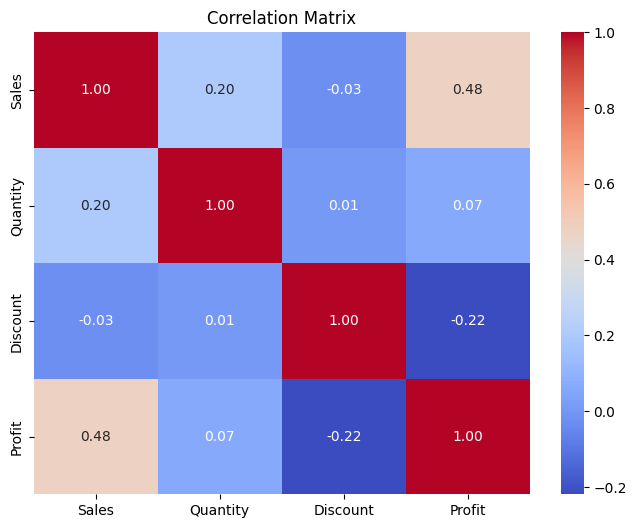

In [71]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Observation: Sales shows a moderate positive correlation with Profit (0.48), while Discount has a weak negative correlation with Profit (-0.22). Quantity shows very weak relationships with both Sales and Profit.

In [72]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Is Sales Outlier,Is Profit Outlier,Shipping Duration,Profit Margin
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,False,False,3,16.00
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,True,True,3,30.00
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,False,False,4,47.00
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,True,True,7,-40.00
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,False,False,7,11.25


In [73]:
df["Sales Performance Category"] = pd.qcut(
    df["Sales"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [74]:
df["Sales Performance Category"].value_counts()

,count
Sales Performance Category,
Low,3328
High,3328
Medium,3327


In [75]:
df[
    [
        "Sales",
        "Profit",
        "Profit Margin",
        "Order Date",
        "Ship Date",
        "Shipping Duration",
        "Sales Performance Category"
    ]
].head()

,Sales,Profit,Profit Margin,Order Date,Ship Date,Shipping Duration,Sales Performance Category
0,261.9600,41.9136,16.00,2018-11-08,2018-11-11,3,High
1,731.9400,219.5820,30.00,2018-11-08,2018-11-11,3,High
2,14.6200,6.8714,47.00,2018-06-12,2018-06-16,4,Low
3,957.5775,-383.0310,-40.00,2017-10-11,2017-10-18,7,High
4,22.3680,2.5164,11.25,2017-10-11,2017-10-18,7,Low


In [76]:
df[
    [
        "Profit Margin",
        "Shipping Duration"
    ]
].describe()

,Profit Margin,Shipping Duration
count,9983.000000,9983.000000
mean,12.006686,3.958129
std,46.694184,1.748758
min,-275.000000,0.000000
25%,7.500000,3.000000
50%,27.000000,4.000000
75%,36.250000,5.000000
max,50.000000,7.000000


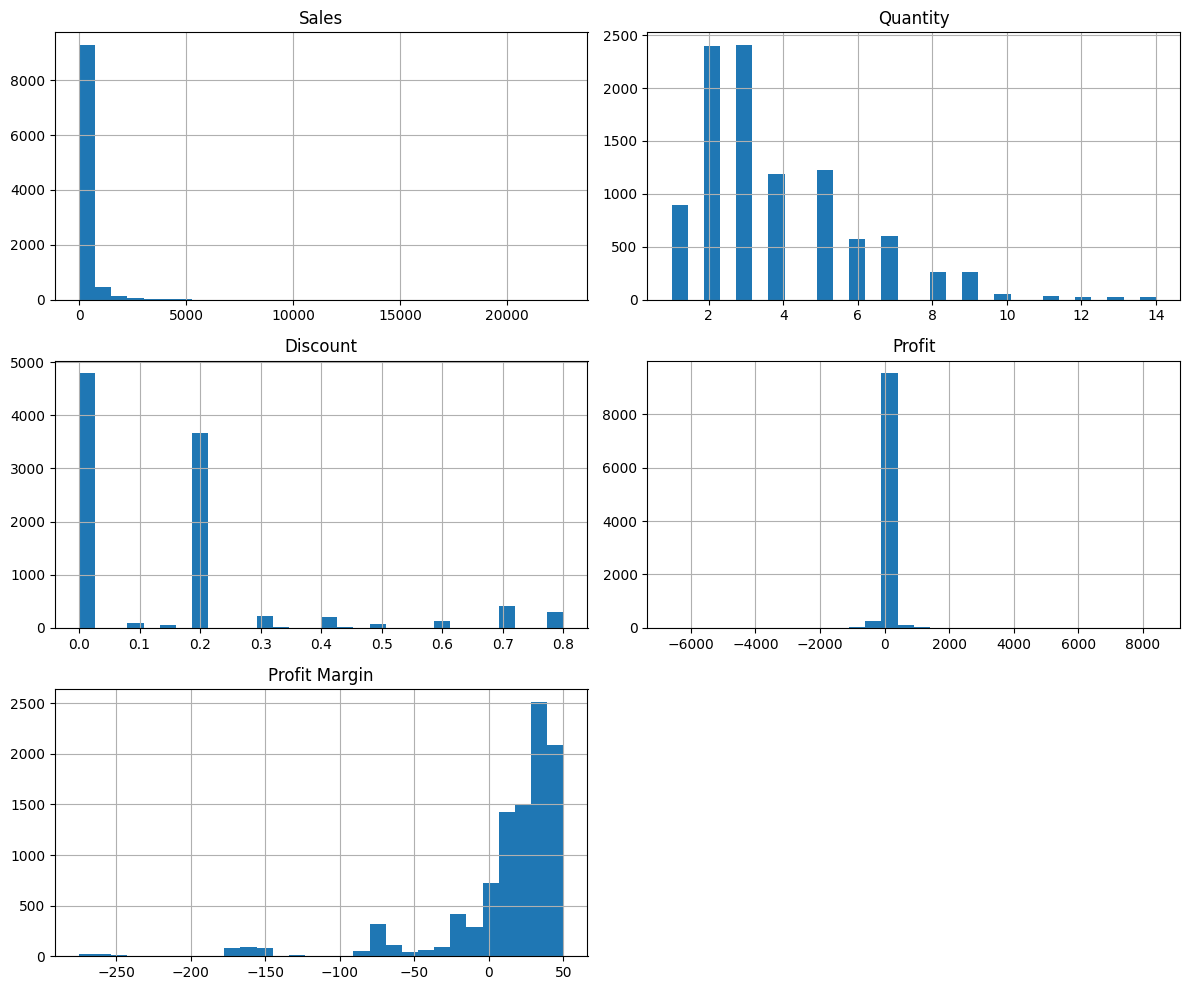

In [77]:
#Statistical

df[["Sales", "Quantity", "Discount", "Profit", "Profit Margin"]].hist(
    figsize=(12, 10), bins=30
)
plt.tight_layout()
plt.show()


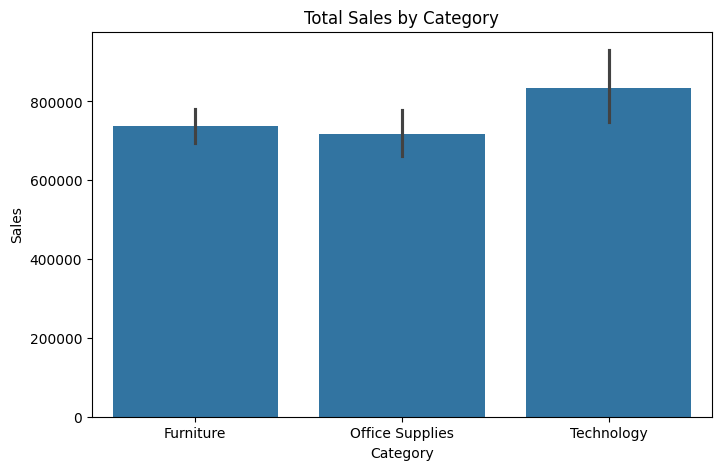

In [78]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="sum"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

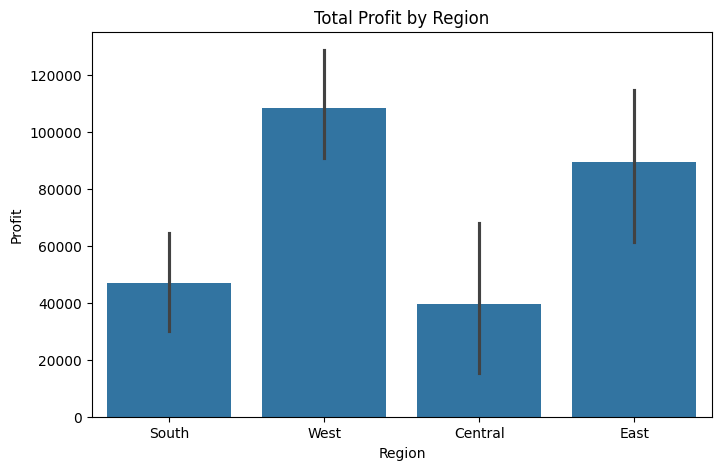

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    estimator="sum"
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

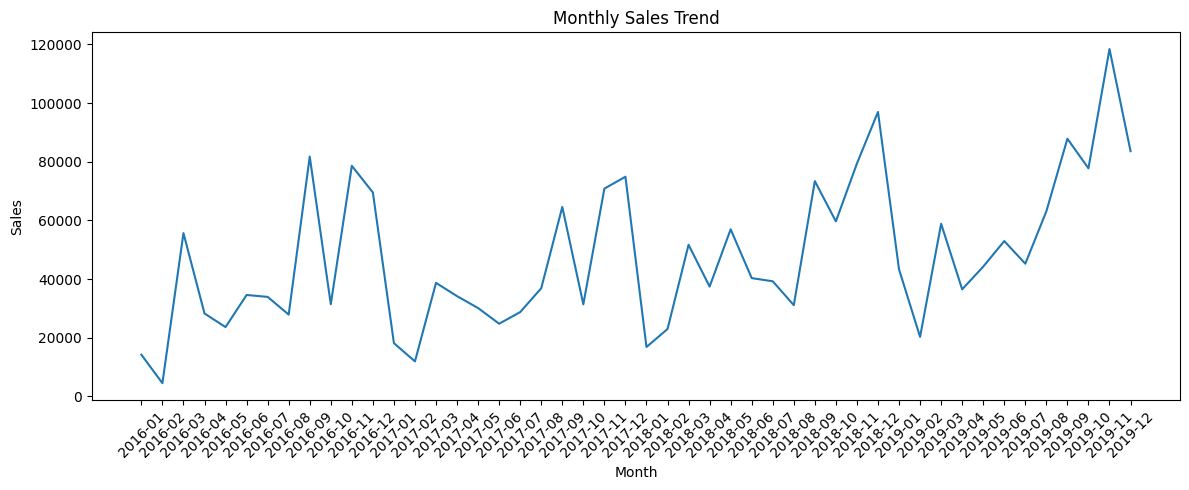

In [80]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

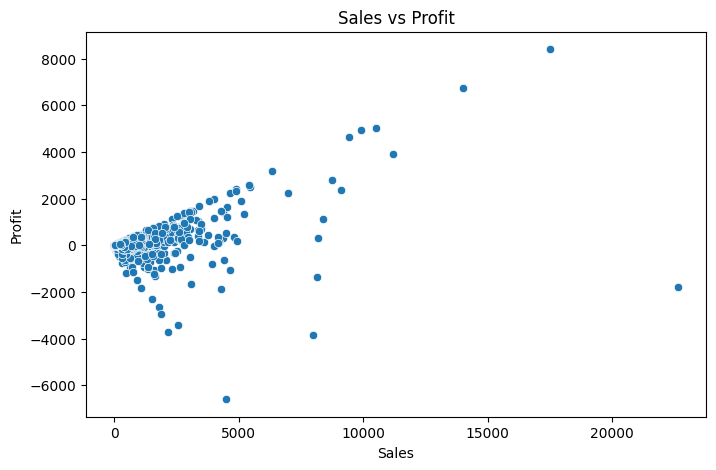

In [81]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

**Overall Observation: The visualizations show an overall growth in sales over time, with noticeable monthly fluctuations. Technology leads in total sales, while the West region generates the highest total profit. The Sales vs Profit plot also shows a positive relationship between sales and profit, with some notable outliers and loss-making transactions.**






# Modular Analytical Functions (Scalable Workflow)

The repeated groupby-based analyses above are wrapped into reusable functions below. Each function takes the dataframe as input and returns a structured result, so the same workflow can be re-run on any filtered slice of the data (e.g. a single year or region) without duplicating code.

In [82]:
def sales_analysis(data):
    """Returns key sales breakdowns: by category, region, year, and month."""
    return {
        "by_category": data.groupby("Category")["Sales"].sum().sort_values(ascending=False),
        "by_region": data.groupby("Region")["Sales"].sum().sort_values(ascending=False),
        "by_year": data.groupby(data["Order Date"].dt.year)["Sales"].sum(),
        "by_month": data.groupby(data["Order Date"].dt.to_period("M"))["Sales"].sum(),
    }


def profitability_analysis(data):
    """Returns key profit breakdowns: by category, region, and sub-category."""
    return {
        "by_category": data.groupby("Category")["Profit"].sum().sort_values(ascending=False),
        "by_region": data.groupby("Region")["Profit"].sum().sort_values(ascending=False),
        "by_subcategory": (
            data.groupby(["Category", "Sub-Category"])["Profit"]
            .sum()
            .sort_values(ascending=True)
        ),
    }


def customer_analysis(data, top_n=10):
    """Returns top customers by sales/profit and overall segment performance."""
    return {
        "top_by_sales": data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(top_n),
        "top_by_profit": data.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(top_n),
        "by_segment": (
            data.groupby("Segment")
            .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"),
                 Orders=("Order ID", "nunique"), Customers=("Customer ID", "nunique"))
            .sort_values("Sales", ascending=False)
        ),
    }


def product_analysis(data, top_n=10):
    """Returns top and worst-performing products by profit."""
    profit_by_product = data.groupby("Product Name")["Profit"].sum().sort_values(ascending=False)
    return {
        "top_by_sales": data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(top_n),
        "top_by_profit": profit_by_product.head(top_n),
        "worst_by_profit": profit_by_product.sort_values(ascending=True).head(top_n),
    }


def run_full_analysis(data):
    """Runs the complete modular analytical workflow and returns all results in one dict."""
    return {
        "sales": sales_analysis(data),
        "profitability": profitability_analysis(data),
        "customers": customer_analysis(data),
        "products": product_analysis(data),
    }


In [83]:
# Demonstration: run the full modular workflow with a single call
results = run_full_analysis(df)

print("Top category by sales:", results["sales"]["by_category"].idxmax())
print("Top region by profit:", results["profitability"]["by_region"].idxmax())
print("Top customer by sales:", results["customers"]["top_by_sales"].idxmax())
print("Most profitable product:", results["products"]["top_by_profit"].idxmax())


Top category by sales: Technology
Top region by profit: West
Top customer by sales: Sean Miller
Most profitable product: Canon imageCLASS 2200 Advanced Copier


**Observation:** Wrapping each analytical dimension (sales, profitability, customers, products) into its own function makes the workflow scalable — the same functions can be re-applied to a filtered subset of the data (e.g. `sales_analysis(q4_orders)` for a single quarter, or `product_analysis(east_sales)` for one region) without rewriting the groupby logic each time.

## Automated KPI Summary

In [84]:
kpis = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Quantity": df["Quantity"].sum(),
    "Total Orders": df["Order ID"].nunique(),
    "Total Customers": df["Customer ID"].nunique(),
    "Average Order Value": df["Sales"].sum() / df["Order ID"].nunique(),
    "Average Profit Margin": df["Profit Margin"].mean()
}

kpi_df = pd.DataFrame(
    list(kpis.items()),
    columns=["KPI", "Value"]
)

kpi_df

,KPI,Value
0,Total Sales,2.288271e+06
1,Total Profit,2.841520e+05
2,Total Quantity,3.782300e+04
3,Total Orders,5.003000e+03
4,Total Customers,7.930000e+02
5,Average Order Value,4.573799e+02
6,Average Profit Margin,1.200669e+01


The business shows a healthy overall performance, generating a positive profit from its sales. However, the average profit margin of 12.01% suggests there is still room to improve profitability, especially by focusing on loss-making products, discount strategies, and high-performing customer segments.

In [85]:
#cleaned/processed dataset
df.to_csv("cleaned_retail_data.csv", index=False)

In [86]:
#KPI report
kpi_df.to_csv("kpi_summary.csv", index=False)

In [87]:
import os

print(os.path.exists("cleaned_retail_data.csv"))
print(os.path.exists("kpi_summary.csv"))

True
True


In [88]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9983 non-null   int64         
 1   Order ID                    9983 non-null   object        
 2   Order Date                  9983 non-null   datetime64[ns]
 3   Ship Date                   9983 non-null   datetime64[ns]
 4   Ship Mode                   9983 non-null   object        
 5   Customer ID                 9983 non-null   object        
 6   Customer Name               9983 non-null   object        
 7   Segment                     9983 non-null   object        
 8   Country/Region              9983 non-null   object        
 9   City                        9983 non-null   object        
 10  State                       9983 non-null   object        
 11  Postal Code                 9983 non-null   float64       
 1

Conclusion: The cleaned dataset and KPI report were successfully exported and verified, with 9,983 complete records across 24 columns.

In [89]:
categorical_cols = [
    "Ship Mode",
    "Segment",
    "Country/Region",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

In [90]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9983 non-null   int64         
 1   Order ID                    9983 non-null   object        
 2   Order Date                  9983 non-null   datetime64[ns]
 3   Ship Date                   9983 non-null   datetime64[ns]
 4   Ship Mode                   9983 non-null   category      
 5   Customer ID                 9983 non-null   object        
 6   Customer Name               9983 non-null   object        
 7   Segment                     9983 non-null   category      
 8   Country/Region              9983 non-null   category      
 9   City                        9983 non-null   object        
 10  State                       9983 non-null   object        
 11  Postal Code                 9983 non-null   float64       
 1

The categorical columns were converted from object to category dtype. This is more memory-efficient because categorical columns contain a limited number of repeated values. As a result, memory usage decreased from 8.5 MB to 5.2 MB. The dataset still contains 9,983 records and 24 columns, with no missing values.

Observation: Boxplots confirm the presence of outliers in both Sales and Profit across all categories, particularly Technology, which shows the widest spread and the most extreme high-value transactions.

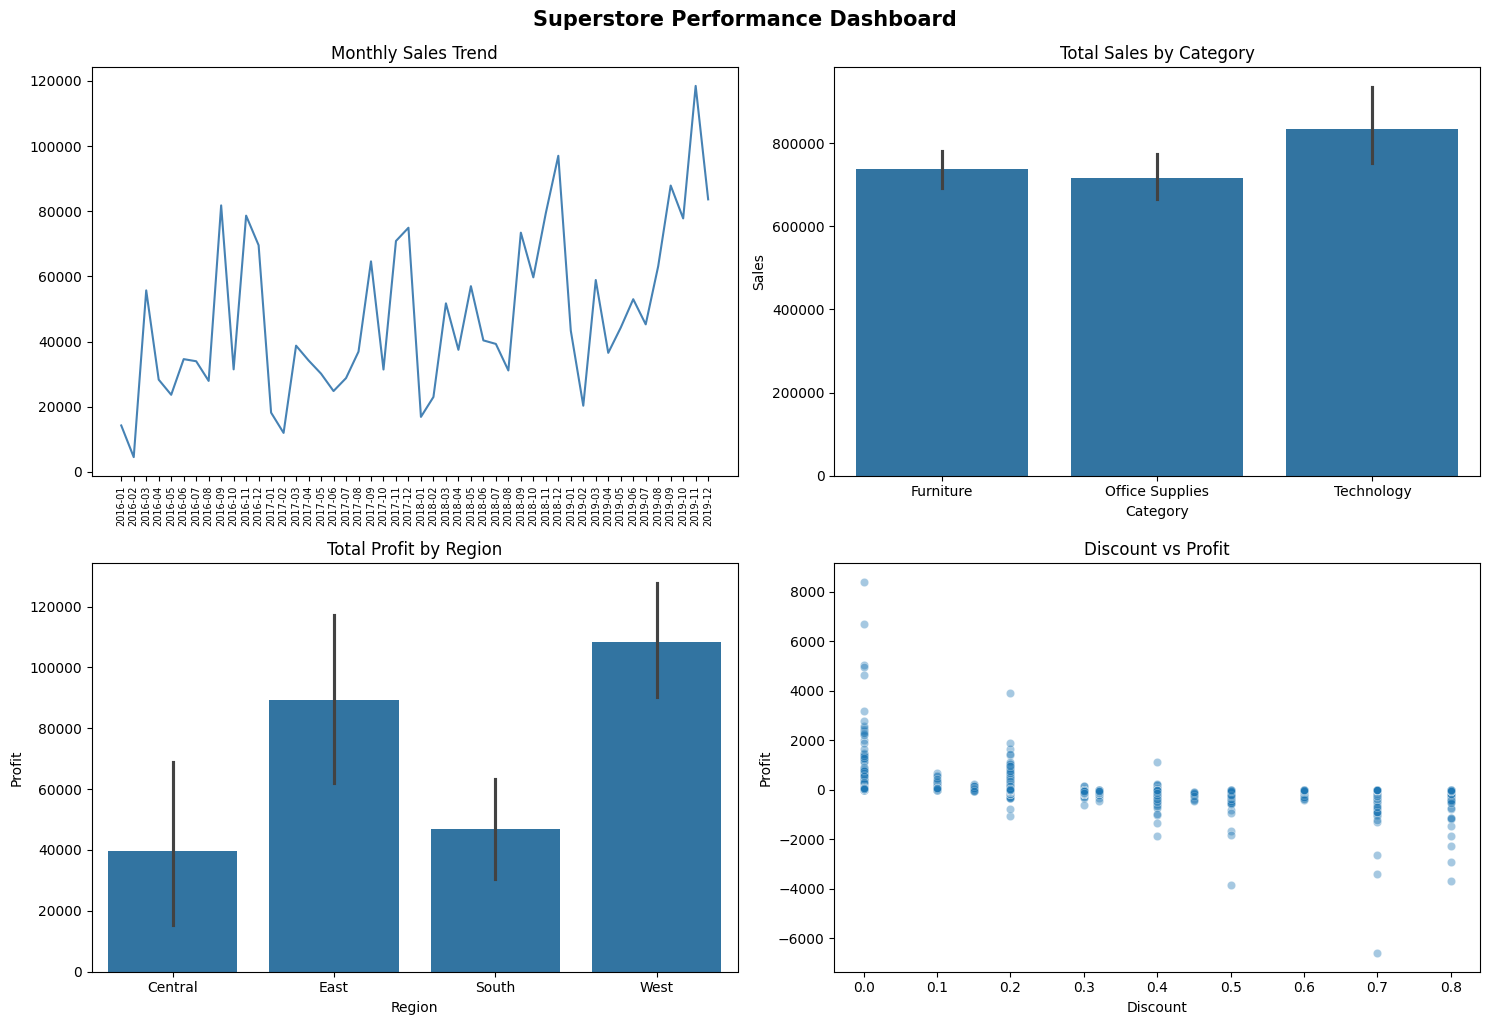

In [91]:
# Dashboard-style summary figure: 4 panels in one view
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Monthly sales trend
monthly_sales_plot = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
axes[0, 0].plot(monthly_sales_plot.index.astype(str), monthly_sales_plot.values, color="steelblue")
axes[0, 0].set_title("Monthly Sales Trend")
axes[0, 0].tick_params(axis='x', rotation=90, labelsize=7)

# Panel 2: Sales by category
sns.barplot(data=df, x="Category", y="Sales", estimator="sum", ax=axes[0, 1])
axes[0, 1].set_title("Total Sales by Category")

# Panel 3: Profit by region
sns.barplot(data=df, x="Region", y="Profit", estimator="sum", ax=axes[1, 0])
axes[1, 0].set_title("Total Profit by Region")

# Panel 4: Discount vs Profit
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title("Discount vs Profit")

plt.tight_layout()
plt.suptitle("Superstore Performance Dashboard", y=1.02, fontsize=15, fontweight="bold")
plt.show()


# Automated Analytical Report Generation

In [92]:
def generate_analytical_report(df, kpis):
    """Builds a dynamic, text-based analytical report from the current dataframe and KPI dict."""

    top_category = df.groupby("Category")["Sales"].sum().idxmax()
    top_region_profit = df.groupby("Region")["Profit"].sum().idxmax()
    worst_subcategory = (
        df.groupby("Sub-Category")["Profit"].sum().idxmin()
    )
    best_month = (
        df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum().idxmax()
    )
    corr_sales_profit = df[["Sales", "Profit"]].corr().iloc[0, 1]

    report_lines = []
    report_lines.append("=" * 60)
    report_lines.append("SUPERSTORE SALES - AUTOMATED ANALYTICAL REPORT")
    report_lines.append("=" * 60)
    report_lines.append("")
    report_lines.append("1. KEY PERFORMANCE INDICATORS")
    report_lines.append("-" * 60)
    for k, v in kpis.items():
        if isinstance(v, float):
            report_lines.append(f"  - {k}: {v:,.2f}")
        else:
            report_lines.append(f"  - {k}: {v:,}")
    report_lines.append("")
    report_lines.append("2. KEY INSIGHTS")
    report_lines.append("-" * 60)
    report_lines.append(f"  - Top-selling category: {top_category}")
    report_lines.append(f"  - Most profitable region: {top_region_profit}")
    report_lines.append(f"  - Least profitable sub-category: {worst_subcategory}")
    report_lines.append(f"  - Best sales month: {best_month}")
    report_lines.append(f"  - Sales-Profit correlation: {corr_sales_profit:.2f}")
    report_lines.append("")
    report_lines.append("3. RECOMMENDATIONS")
    report_lines.append("-" * 60)
    report_lines.append("  - Review pricing/discount strategy for loss-making sub-categories.")
    report_lines.append("  - Investigate high-discount transactions, since discount is")
    report_lines.append("    negatively correlated with profit.")
    report_lines.append("  - Reinforce marketing spend around peak months to build on")
    report_lines.append("    seasonal demand.")
    report_lines.append("")
    report_lines.append("=" * 60)

    return "\n".join(report_lines)


report_text = generate_analytical_report(df, kpis)
print(report_text)


SUPERSTORE SALES - AUTOMATED ANALYTICAL REPORT

1. KEY PERFORMANCE INDICATORS
------------------------------------------------------------
  - Total Sales: 2,288,271.49
  - Total Profit: 284,152.04
  - Total Quantity: 37,823
  - Total Orders: 5,003
  - Total Customers: 793
  - Average Order Value: 457.38
  - Average Profit Margin: 12.01

2. KEY INSIGHTS
------------------------------------------------------------
  - Top-selling category: Technology
  - Most profitable region: West
  - Least profitable sub-category: Tables
  - Best sales month: 2019-11
  - Sales-Profit correlation: 0.48

3. RECOMMENDATIONS
------------------------------------------------------------
  - Review pricing/discount strategy for loss-making sub-categories.
  - Investigate high-discount transactions, since discount is
    negatively correlated with profit.
  - Reinforce marketing spend around peak months to build on
    seasonal demand.



/tmp/ipykernel_963/2449419805.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_category = df.groupby("Category")["Sales"].sum().idxmax()
/tmp/ipykernel_963/2449419805.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_region_profit = df.groupby("Region")["Profit"].sum().idxmax()
/tmp/ipykernel_963/2449419805.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Sub-Category")["Profit"].sum().idxmin(

In [93]:
# Save the automated report to disk
with open("analytical_report.txt", "w") as f:
    f.write(report_text)

print("Report saved to analytical_report.txt")


Report saved to analytical_report.txt


# Automatic Export of Visual Reports

Saved: visuals/sales_by_category.png


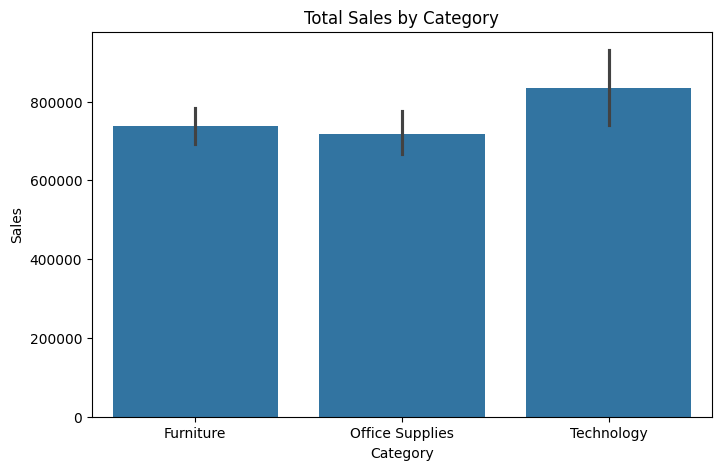

Saved: visuals/profit_by_region.png


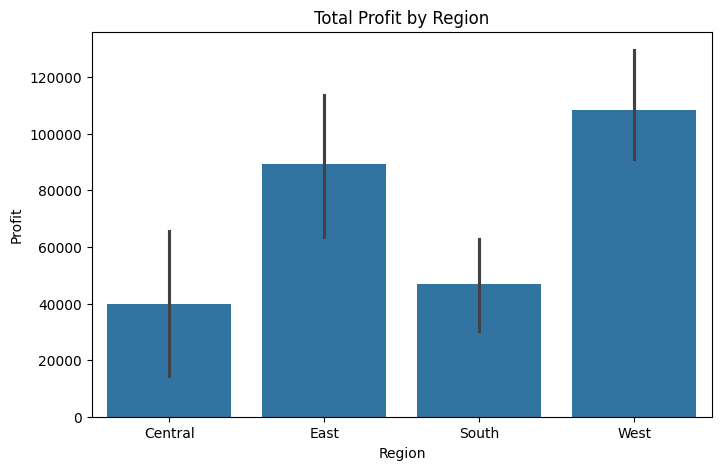

Saved: visuals/monthly_sales_trend.png


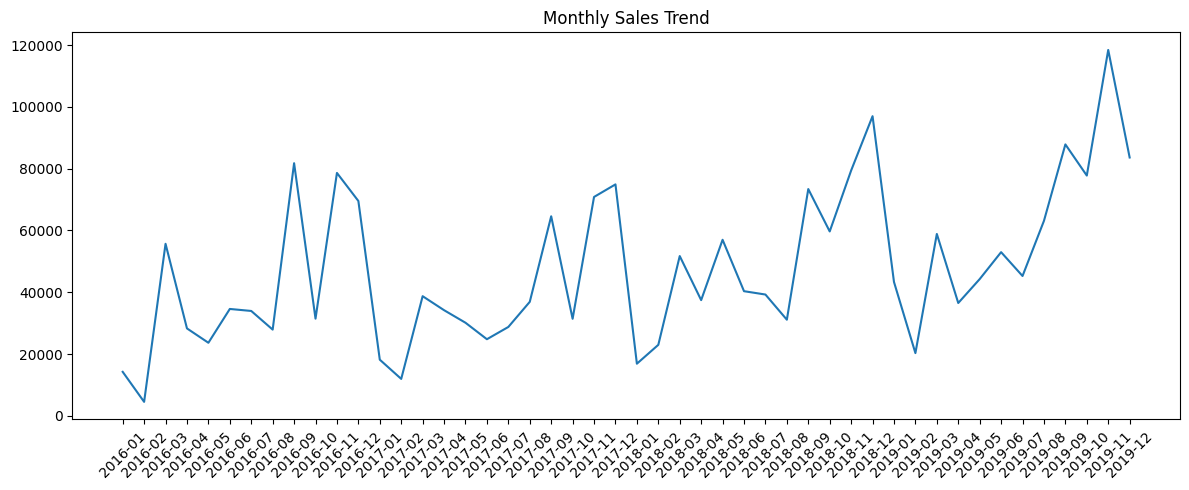

Saved: visuals/correlation_matrix.png


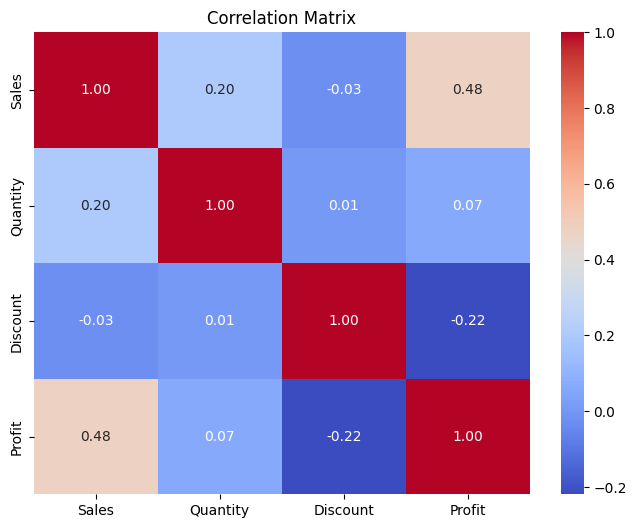


All visual reports exported automatically to the 'visuals/' folder.


In [94]:
import os

VISUALS_DIR = "visuals"
os.makedirs(VISUALS_DIR, exist_ok=True)


def save_current_fig(name):
    """Saves the current matplotlib figure to the visuals folder as a PNG."""
    path = os.path.join(VISUALS_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")


# Re-generate and auto-save the key charts
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Category", y="Sales", estimator="sum")
plt.title("Total Sales by Category")
save_current_fig("sales_by_category")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Region", y="Profit", estimator="sum")
plt.title("Total Profit by Region")
save_current_fig("profit_by_region")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales_plot.index.astype(str), monthly_sales_plot.values)
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
save_current_fig("monthly_sales_trend")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
save_current_fig("correlation_matrix")
plt.show()

print("\nAll visual reports exported automatically to the 'visuals/' folder.")


# Optimizing DataFrame Operations & Memory Usage

In [95]:
# Further memory optimization: downcast numeric columns
def optimize_memory(df):
    df = df.copy()
    before = df.memory_usage(deep=True).sum() / 1024**2

    int_cols = df.select_dtypes(include=["int64"]).columns
    float_cols = df.select_dtypes(include=["float64"]).columns

    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast="float")

    after = df.memory_usage(deep=True).sum() / 1024**2

    print(f"Memory before optimization: {before:.2f} MB")
    print(f"Memory after optimization:  {after:.2f} MB")
    print(f"Reduction: {(1 - after / before) * 100:.1f}%")

    return df


df = optimize_memory(df)
df.info(memory_usage="deep")


Memory before optimization: 5.21 MB
Memory after optimization:  4.87 MB
Reduction: 6.6%
<class 'pandas.core.frame.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9983 non-null   int16         
 1   Order ID                    9983 non-null   object        
 2   Order Date                  9983 non-null   datetime64[ns]
 3   Ship Date                   9983 non-null   datetime64[ns]
 4   Ship Mode                   9983 non-null   category      
 5   Customer ID                 9983 non-null   object        
 6   Customer Name               9983 non-null   object        
 7   Segment                     9983 non-null   category      
 8   Country/Region              9983 non-null   category      
 9   City                        9983 non-null   object        
 10  State                       9983 non-

In [96]:
# Vectorized operations vs. row-wise apply: performance comparison
import time

start = time.time()
_ = df["Sales"] * (1 - df["Discount"])
vectorized_time = time.time() - start

start = time.time()
_ = df.apply(lambda row: row["Sales"] * (1 - row["Discount"]), axis=1)
apply_time = time.time() - start

print(f"Vectorized operation time: {vectorized_time:.5f} sec")
print(f"Row-wise apply time:       {apply_time:.5f} sec")
print(f"Vectorized is ~{apply_time / vectorized_time:.1f}x faster")


Vectorized operation time: 0.00073 sec
Row-wise apply time:       0.09772 sec
Vectorized is ~134.3x faster


Observation: Vectorized pandas/NumPy operations are dramatically faster than row-wise `apply()`, since they operate on entire arrays at once instead of looping in Python. For large datasets, vectorized operations (or `.values`/NumPy broadcasting) should always be preferred over `apply(axis=1)`.

In [97]:
# Re-export the optimized cleaned dataset (overwrites previous export with optimized dtypes)
df.to_csv("cleaned_retail_data.csv", index=False)
print("Optimized cleaned dataset re-exported: cleaned_retail_data.csv")


Optimized cleaned dataset re-exported: cleaned_retail_data.csv


## Final Summary

This notebook now covers the full required analytical workflow end to end:

- **Import & inspect**: dataset loaded with Pandas; shape, dtypes, and descriptive stats reviewed.
- **Advanced data cleaning**: missing values handled, duplicates explicitly removed, text formats standardized, and outliers in Sales/Profit detected via the IQR method and flagged (not silently dropped).
- **Reusable preprocessing pipeline**: `preprocessing_pipeline()` chains loading, cleaning, feature engineering, and dtype optimization into a single reusable function.
- **Feature engineering**: Profit Margin, Shipping Duration, and Sales Performance Category.
- **Modular analytical functions**: `sales_analysis()`, `profitability_analysis()`, `customer_analysis()`, `product_analysis()`, and `run_full_analysis()` make the workflow scalable to any data subset.
- **Advanced EDA & statistics**: categorical breakdowns, correlation analysis, distribution checks, and monthly/yearly trend analysis.
- **Advanced visualizations**: boxplots, violin plots, heatmaps, pairplots, and a multi-panel dashboard built with Matplotlib and Seaborn.
- **Automated KPI summaries and analytical reports**: `generate_analytical_report()` dynamically builds and exports a text report (`analytical_report.txt`).
- **Automatic export**: the cleaned dataset is saved as CSV, and key charts are auto-saved as PNGs into a `visuals/` folder.
- **Performance optimization**: numeric columns downcast, categorical dtypes applied, and vectorized operations shown to outperform row-wise `apply()`.